<a href="https://colab.research.google.com/github/romavallejo/TC3009C.600_AIClass/blob/main/P1_M1_%20PythonLib_Statistics/DiabetesRegresionMetrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

#load data
diabetes= load_diabetes()
X = diabetes.data
y = diabetes.target

#split data
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

#create models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

#train and test for MSE
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  print(f"{name} MSE: {mse:.2f}")

Linear Regression MSE: 2900.19
Ridge Regression MSE: 3077.42
Random Forest MSE: 2952.01


LinearRegression MAE: 52.26
Ridge MAE: 55.96
Lasso MAE: 54.28


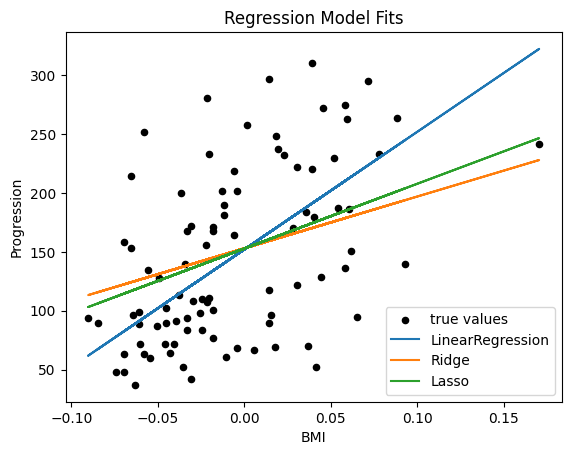

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X = diabetes.data[:, np.newaxis,2]
y = diabetes.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    }
plt.scatter(X_test, y_test, color="black", s=20, marker='o', label='true values')

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    plt.plot(X_test, predictions, label=name)
    mae = mean_absolute_error(y_test, predictions)
    print(f"{name} MAE: {mae:.2f}")
plt.title("Regression Model Fits")
plt.xlabel("BMI")
plt.ylabel("Progression")
plt.legend()
plt.show()

LinearRegression RMSE: 62.33
DecisionTreeRegressor RMSE: 68.98
RandomForestRegressor RMSE: 66.05


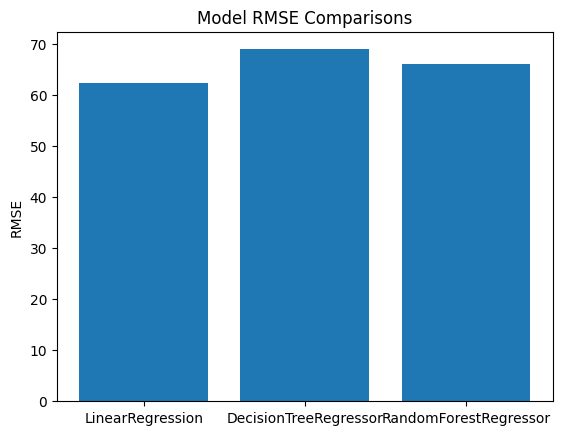

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    }

rmse_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    rmse_scores.append((name,rmse))
    print(f'{name} RMSE: {rmse:.2f}')

#plot
names, scores = zip(*rmse_scores)
plt.bar(names, scores)
plt.ylabel('RMSE')
plt.title('Model RMSE Comparisons')
plt.show()

Linear Regression R^2: 0.28
Decision Tree R^2: 0.12
Random Forest R^2: 0.19


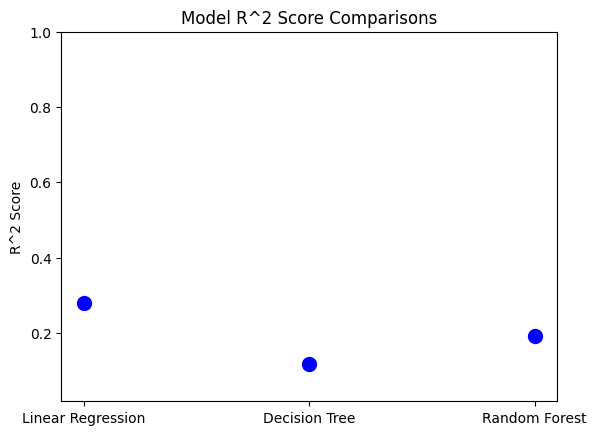

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42))
]

r2_scores = []

for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    r2 = model.score(X_test, y_test)
    r2_scores.append((name, r2))
    print(f'{name} R^2: {r2:.2f}')

names, scores = zip(*r2_scores)
plt.scatter(names, scores, color='blue', s=100)
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('R^2 Score')
plt.title('Model R^2 Score Comparisons')
plt.ylim(min(scores) - 0.1, 1)
plt.show()

Linear Regression MAPE: 37.50%
Ridge Regression MAPE: 42.57%
Lasso Regression MAPE: 47.11%
Decision Tree MAPE: 47.33%
Random Forest MAPE: 40.01%
SVR MAPE: 49.03%


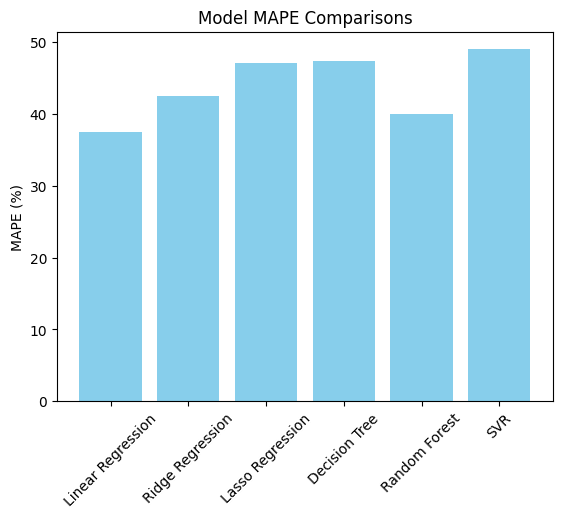

In [ ]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    return np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices])) * 100

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVR': SVR()
}

mape_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, predictions)
    mape_scores.append((name, mape))
    print(f'{name} MAPE: {mape:.2f}%')

names, scores = zip(*mape_scores)
plt.bar(names, scores, color='skyblue')
plt.ylabel('MAPE (%)')
plt.title('Model MAPE Comparisons')
plt.xticks(rotation=45)
plt.show()

Linear Regression RMSLE: 0.42
Ridge Regression RMSLE: 0.43
Lasso Regression RMSLE: 0.46
Decision Tree RMSLE: 0.59
Random Forest RMSLE: 0.42
SVR RMSLE: 0.48


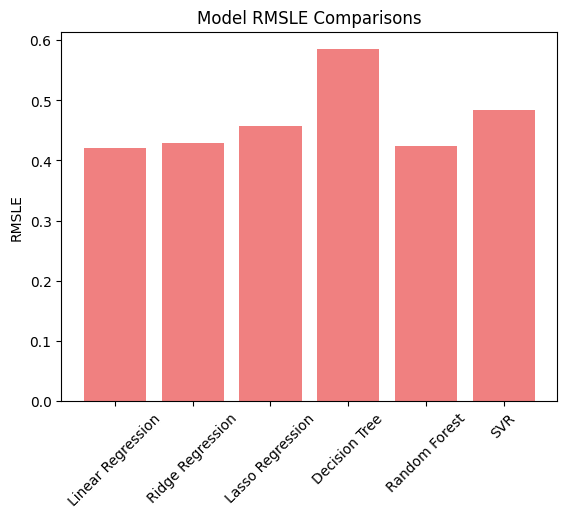

In [ ]:
from sklearn.metrics import mean_squared_log_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def root_mean_squared_log_error(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-10, np.inf)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVR': SVR()
}

rmsle_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmsle = root_mean_squared_log_error(y_test, predictions)
    rmsle_scores.append((name, rmsle))
    print(f'{name} RMSLE: {rmsle:.2f}')

names, scores = zip(*rmsle_scores)
plt.bar(names, scores, color='lightcoral')
plt.ylabel('RMSLE')
plt.title('Model RMSLE Comparisons')
plt.xticks(rotation=45)
plt.show()